<a href="https://colab.research.google.com/github/kchenTTP/python-series/blob/main/web_apis/Consuming_Web_APIs_With_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Consuming Web APIs with Python**

An **API** *(Application Programming Interface)* is the digital interface that allows different software applications to communicate and exchange data. In the context of the web, an API is a set of rules and protocols that define how a **client** *(a browser, a Python script, etc.)* can request information from a **server** *(the remote database, service, etc.)*.

In this session, we will cover the essentials of **networking** (how data travels across the internet) and practice interacting with live data sources using Python's requests library.

### **Table of Contents**
- [Networking 101](#scrollTo=EagKIm3iZL3Z)
- [Accessing APIs](#scrollTo=rjRdjirqh2nh)
- [Example: Spoonacular API](#scrollTo=UcLMBb336oim)
- [Example: OpenWeather API](#scrollTo=w4d1Ziv86uMA)
- [Example: NASA API](#scrollTo=LZi7ADAE61kC)


## **Networking 101**

Information is exchanged on the web via the **hypertext transfer protocol (HTTP)**. Every time you use a browser or write code to fetch data, you are participating in an **HTTP Request & Response cycle**.


### **The Request & Response Cycle**

An API call is simply a structured exchange between a **Client** and a **Server**.

<br>

<figure align="center">
  <img src="https://raw.githubusercontent.com/kchenTTP/python-series/refs/heads/main/web_apis/assets/request_response_cycle.png" alt="The request and response cycle diagram" />
  <figcaption>Simplified request and response cycle</figcaption>
</figure>


#### **The Request _(What you send)_**

To initiate a connection, your script sends a request containing:

- **URL _(Endpoint)_:** The web address you are hitting

- **Parameters:** Extra information added to the URL _(ex: `?api_key=DEMO_KEY&date=2023-01-01`)_

- **[Method](https://developer.mozilla.org/en-US/docs/Web/HTTP/Reference/Methods):** The action you want to perform

  - `GET`: Retrieve data from a server

  - `POST`: Send or create new data on a server

- **[Headers](https://developer.mozilla.org/en-US/docs/Web/HTTP/Reference/Headers):** Metadata about the request _(we won't talk about headers in this class but every HTTP request and response has a header)_


#### **The Response _(What you get back)_**

After processing your request, the server sends back a response:

- **[Status Code](https://developer.mozilla.org/en-US/docs/Web/HTTP/Reference/Status):** A 3 digit number indicating the result

  - `200`: Success _(OK)_

  - `401`: Unauthorized _(Missing or invalid API Key)_

  - `404`: Not Found _(The URL doesn't exist)_

- **Body _(Payload)_:** The actual data, usually formatted as **JSON** _(JavaScript Object Notation)_


## **Accessing APIs**

While every service is slightly different, using most modern web APIs follow a standard 3 step workflow:

<br>

### 1. Documentation

The **API Documentation** is the instruction manual provided by the developers. It tells you:

- The purpose of the API

- The **Base URL** _(the root address of the API)_

- The **Endpoints** _(the paths for different resources)_

- The **Required Parameters** _(what info you need to provide)_

### 2. Authentication

Most APIs require you to sign up for an account to receive an **API Key**, which acts as a digital *"passcard"* to identify your requests. While there are other ways of authentication, we'll be using APIs that use an API key for authentication or ones that don't require one.

> ❗ **IMPORTANT**: **DO NOT** share your authentication info publicly or save it directly in your code. If someone steals your key, they can use up your credits, get your account banned, or worse.

### 3. Rate Limits

APIs often have **Rate Limits**, which is a cap on how many requests you can make per a set period of time. Going over the limit will usually result in a **429 Too Many Requests** error.


## **Import Libraries**

We'll be using the following libraries for this session:

- [`requests`](https://docs.python-requests.org/en/latest/index.html): Handles simple HTTP requests and responses in Python.

- [`google.colab`](https://github.com/googlecolab/colabtools): Provides utilities to securely access environment variables within the Colab environment.

- [`pprint`](https://docs.python.org/3/library/pprint.html): Short for "pretty-print"; it formats complex data structures into more readable layouts.

- [`IPython.display`](https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html#module-IPython.display): Used to render rich content like images, HTML, or videos directly inside your notebook cells.


In [ ]:
import requests
from google.colab import userdata
from pprint import pp
from IPython.display import display, Image, HTML

## **Examples**

Now let's look at some examples with these popular APIs.

<table>
  <tr>
    <th>API</th>
    <th>Service</th>
    <th>Auth Method</th>
  </tr>
  <tr>
    <td><a href="#scrollTo=UcLMBb336oim"><strong>Spoonacular API</strong></a></td>
    <td>Recipe search, nutrition, food information.</td>
    <td>API Key</td>
  </tr>
  <tr>
    <td><a href="#scrollTo=w4d1Ziv86uMA"><strong>OpenWeather API</strong></a></td>
    <td>Real-time weather, forecasts, air quality.</td>
    <td>API Key</td>
  </tr>
  <tr>
    <td><a href="#scrollTo=LZi7ADAE61kC"><strong>NASA API</strong></a></td>
    <td>NASA data and imagery.</td>
    <td>API Key</td>
  </tr>
  <tr>
    <td><a href="#scrollTo="><strong>openFDA API</strong></a></td>
    <td></td>
    <td>None</td>
  </tr>
  <tr>
    <td><a href="#scrollTo="><strong>NYPL Digital Collections API</strong></a></td>
    <td></td>
    <td></td>
  </tr>
  <tr>
    <td><a href="#scrollTo="><strong>Library of Congress APIs</strong></a></td>
    <td></td>
    <td></td>
  </tr>
  <tr>
    <td><a href="#scrollTo="><strong>QuickChart API</strong></a></td>
    <td></td>
    <td></td>
  </tr>
</table>

## **Spoonacular API**

Spoonacular is an online food and recipe database. In this example, we will be using the Spoonacular API to find recipes and ingredients.


### **Preparation**

- **Sign Up:** Create an account on the [Spoonacular Console](https://spoonacular.com/food-api/console#Profile) to obtain your **API Key**.

- **Check Quotas:** Review the [Rate Limiting Rules](https://spoonacular.com/food-api/docs#Quotas) to understand daily request limits.

- **Authentication:** Read the [Authentication Guide](https://spoonacular.com/food-api/docs#Authentication) to see how to include your key in your requests.


### **Storing API Keys**

> ❗ **DO NOT** store your API keys directly in your code.  
> 💡 You should instead store API keys as **Environment Variables!**

<br>

Google Colab allows you to store secrets _(api keys, passwords, sensative information, ...)_ as environment variables:


1. Click on the `Secrets` menu _(key icon)_ on the left side to manage your environment variables.

2. Click on `+ Add new secret`.

3. Type `SPOON_KEY` into the "Name" field and paste your newly obtained API key into the "Value" field _(cannot contain space)_.

4. Turn on "Notebook access"


In [ ]:
# Get environment variables from colab like this, make sure you use the exact same name

SPOON_KEY = userdata.get('SPOON_KEY')

> 💡 **NOTE**: For environment variables and constants, `SCREAMING_SNAKE_CASE` is the convention

### **Searching For Recipes**

To find recipes, we use the **`complexSearch`** endpoint. This is Spoonacular's most flexible tool, allowing you to filter by ingredients, diet, nutrition, and more.

- **Endpoint:** `https://api.spoonacular.com/recipes/complexSearch`

- **Documentation:** [Search Recipes Complex](https://spoonacular.com/food-api/docs#Search-Recipes-Complex)

Read the documentation to identify which **parameters** (like `query`, `cuisine`, or `diet`) you can use to narrow down your results.


In [ ]:
# Store the API endpoint
recipe_endpoint = "https://api.spoonacular.com/recipes/complexSearch"

Let's filter the results with the `query`, `cuisine`, `intolerances`, and `number` parameters:

In [ ]:
# Store the parameters in a dictionary to pass into the requests.get method

params = {
  "apiKey": SPOON_KEY,
  "query": "pasta",
  "cuisine": "Italian",
  "intolerances": "Dairy",
  "number": 2
}

In [ ]:
# Pass the API endpoint and parameters into the requests.get method
response = requests.get(recipe_endpoint, params=params)

# Raises an error if response status is not 200
response.raise_for_status()

# Convert JSON data to Python dictionary
data = response.json()

pp(data)

### **Finding Ingredients**

Great! Now that we have a recipe ID from our search, let's fetch the specific ingredients required to make it using the **Get Recipe Information** endpoint.

- **Endpoint:** `https://api.spoonacular.com/recipes/{id}/information`

- **Documentation:** [Get Recipe Information (Ingredients by ID)](https://spoonacular.com/food-api/docs#Get-Recipe-Information)


In [ ]:
# Let's pick one recipe and store it's id number
recipe_id = data["results"][0]["id"]

# Build the endpoint url with our recipe id
recipe_info_endpoint = f"https://api.spoonacular.com/recipes/{recipe_id}/information"

In [ ]:
# Your code goes here

# Step 1: Create a dictionary that holds all the parameters (including your API key)
params = {}

# Step 2: Make the api call and store the response in a variable named `recipe_info`


In [ ]:
#@title Solution (Write your own code before checking the answer)

params = {
  "apiKey": SPOON_KEY,
  "includeNutrition": True
}

response = requests.get(recipe_info_endpoint, params=params)

response.raise_for_status()

recipe_info = response.json()

pp(recipe_info)

### **Parsing the Information**

Now that we've got the full JSON response, let's extract some details to create a recipe summary.


In [ ]:
# Let's get the recipe title
recipe_title = recipe_info.get("title")
pp(recipe_title)

In [ ]:
# Store the image of the recipe
recipe_img = recipe_info.get("image")
display(Image(url=recipe_img))

In [ ]:
# Store the amount of time it takes to make the recipe
ready_minutes = int(recipe_info.get("readyInMinutes"))  # cast to integer in case it's a string
pp(ready_minutes)

In [ ]:
# Store the ingredients required to make this recipe
ingredients = [item.get("original") for item in recipe_info.get("extendedIngredients", [])]
pp(ingredients)

In [ ]:
# Store the instructions for the recipe
recipe_instructions = recipe_info.get("instructions")
display(HTML(recipe_instructions))

In [ ]:
# Store the nutrition info of the recipe
recipe_nutrients = recipe_info.get("nutrition", []).get("nutrients",[])
recipe_nutrients = {item.get("name"): (item.get("amount"), item.get("unit")) for item in recipe_nutrients}
pp(recipe_nutrients)

Congrats! You've successfully mastered the basics of consuming a web API. Spoonacular offers much more than just recipe searches, including meal planning, wine pairings, and food trivia.

Check out the full [Spoonacular Documentation](https://spoonacular.com/food-api/docs) to discover more.


## **OpenWeather API**

OpenWeather is an online service that provides real-time, historical, and forecasted weather data. In this example, we will be using the **Current Weather Data** endpoint to retrieve atmospheric conditions for a specific city.


### **Preparation**

- **API Key:** Sign up at the [OpenWeather Portal](https://home.openweathermap.org/users/sign_up) to receive your API key _(`appid`)_.

- **Check Quotas:** Review the [Pricing Page](https://openweathermap.org/price#:~:text=Free%20for%20everyone-,Current,-weather) to understand request limits.


### **Storing API Keys**

> ❗ **DO NOT** store your API keys directly in your code.  
> 💡 You should instead store API keys as **Environment Variables!**

<br>

Google Colab allows you to store secrets _(api keys, passwords, sensative information, ...)_ as environment variables:


1. Click on the `Secrets` menu _(key icon)_ on the left side to manage your environment variables.

2. Click on `+ Add new secret`.

3. Type `WEATHER_KEY` into the "Name" field and paste your newly obtained API key into the "Value" field _(cannot contain space)_.

4. Turn on "Notebook access"


In [ ]:
# Get environment variables from colab like this, make sure you use the exact same name

WEATHER_KEY = userdata.get('WEATHER_KEY')

> 💡 **NOTE**: For environment variables and constants, `SCREAMING_SNAKE_CASE` is the convention


### **Get Current Weather Data For Location**

To get current weather data, we first need to convert a location name or zip code into geographic coordinates _(**Latitude** and **Longitude**)_. We do this using the **Geocoding API**.


#### **Step 1: Get Coordinates _(Geocoding)_**

- **Endpoint:** `http://api.openweathermap.org/geo/1.0/zip?zip={zip code},{country code}&appid={API key}`

- **Documentation:** [Geocoding API](https://openweathermap.org/api/geocoding-api)


In [ ]:
# Store the API endpoint
geo_endpoint = "http://api.openweathermap.org/geo/1.0/zip"

In [ ]:
# Store the parameters in a dictionary to pass into the requests.get method

params = {
  "appid": WEATHER_KEY,
  "zip": 10016
}

In [ ]:
# Pass the API endpoint and parameters into the requests.get method
response = requests.get(geo_endpoint, params=params)

# Raises an error if response status is not 200
response.raise_for_status()

# Convert JSON data to Python dictionary
loc_info = response.json()

pp(loc_info)

#### **Step 2: Get Weather _(Current Weather)_**

Once we have the coordinates, we pass them into the **Current Weather Data** endpoint to retrieve live atmospheric conditions.

- **Endpoint:** `https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={API key}`

- **Documentation:** [Current Weather Data](https://openweathermap.org/current)

Read the documentation to identify which **parameters** (like `units` or `lang`) you can use to modify results.


In [ ]:
# Store the API endpoint
weather_endpoint = "https://api.openweathermap.org/data/2.5/weather"

In [ ]:
# Your code goes here

# Step 1: Create a dictionary that holds all the parameters (including your API key)
params = {}

# Step 2: Make the api call and store the response in a variable named `current_weather`


In [ ]:
#@title Solution (Write your own code before checking the answer)

params = {
  "appid": WEATHER_KEY,
  "lat": loc_info["lat"],
  "lon": loc_info["lon"],
  "units": "imperial"
}

response = requests.get(weather_endpoint, params=params)

response.raise_for_status()

current_weather = response.json()

pp(current_weather)

### **Get Weather Forecast For Location**

To get the weather forecast of a location, call the **5 Day Forecast** endpoint.

- **Endpoint:** `api.openweathermap.org/data/2.5/forecast?lat={lat}&lon={lon}&appid={API key}`

- **Documentation:** [5 Day Forecast](https://openweathermap.org/forecast5?collection=current_forecast)


In [ ]:
# Store the API endpoint
forecast_endpoint = "https://api.openweathermap.org/data/2.5/forecast"

In [ ]:
# Your code goes here

# Step 1: Create a dictionary that holds all the parameters (including your API key)
params = {}

# Step 2: Make the api call and store the response in a variable named `weather_forecast`


In [ ]:
#@title Solution (Write your own code before checking the answer)

params = {
  "appid": WEATHER_KEY,
  "lat": loc_info["lat"],
  "lon": loc_info["lon"],
  "units": "imperial",
  "cnt": 5
}

response = requests.get(forecast_endpoint, params=params)

response.raise_for_status()

weather_forecast = response.json()

pp(weather_forecast)

### **Parsing the Information**

Now that we've got the full JSON response, let's extract some details to create a summary for our weather forecast.


In [ ]:
# Store the name of the city
city = weather_forecast.get("city").get("name")
pp(city)

In [ ]:
# Store the information we need from the list of forecast

forecast_list = []

for timestamp in weather_forecast.get("list"):
  forecast_list.append({
      "datetime": timestamp.get("dt_txt"),
      "weather": timestamp.get("weather")[0].get("main"),
      "temperature": timestamp.get("main").get("temp"),
      "humidity": timestamp.get("main").get("humidity")
  })

pp(forecast_list)

Congrats! You've successfully mastered the basics of consuming a web API. OpenWeather offers a few more free endpoints to view **air pollution** and **weather maps**.

Check out the full [OpenWeather Documentation](https://openweathermap.org/api/air-pollution?collection=environmental) to discover more.


## **NASA API**



### **Storing API Keys**

> ❗ **DO NOT** store your API keys directly in your code.  
> 💡 You should instead store API keys as **Environment Variables!**

<br>

Google Colab allows you to store secrets _(api keys, passwords, sensative information, ...)_ as environment variables:


1. Click on the `Secrets` menu _(key icon)_ on the left side to manage your environment variables.

2. Click on `+ Add new secret`.

3. Type `NASA_KEY` into the "Name" field and paste your newly obtained API key into the "Value" field _(cannot contain space)_.


## Old

Link to the slideshow for this class: https://docs.google.com/presentation/d/e/2PACX-1vSs5R0bwdUjm3pLFiWfnw3MRoZf4ZCQts1qhG5xrZfWI1Z9EyslHI93wgkI6DAfsxSPstKwhsR8e1om/pub?start=false&loop=false&delayms=3000

Links to the JSON examples used in class:
* [JSON Example 1](https://tinyurl.com/jsonExample1)
* [JSON Example 2](https://tinyurl.com/jsonExample2)
* [JSON Example 3](https://tinyurl.com/jsonExample4)

### Sign up for an API key

*   List item
*   List item



Create an account here: https://home.openweathermap.org/users/sign_up

They will send a confirmation email soon after you sign up. Once you click the link in that email, go back to the home page (https://home.openweathermap.org/) and click "API keys":

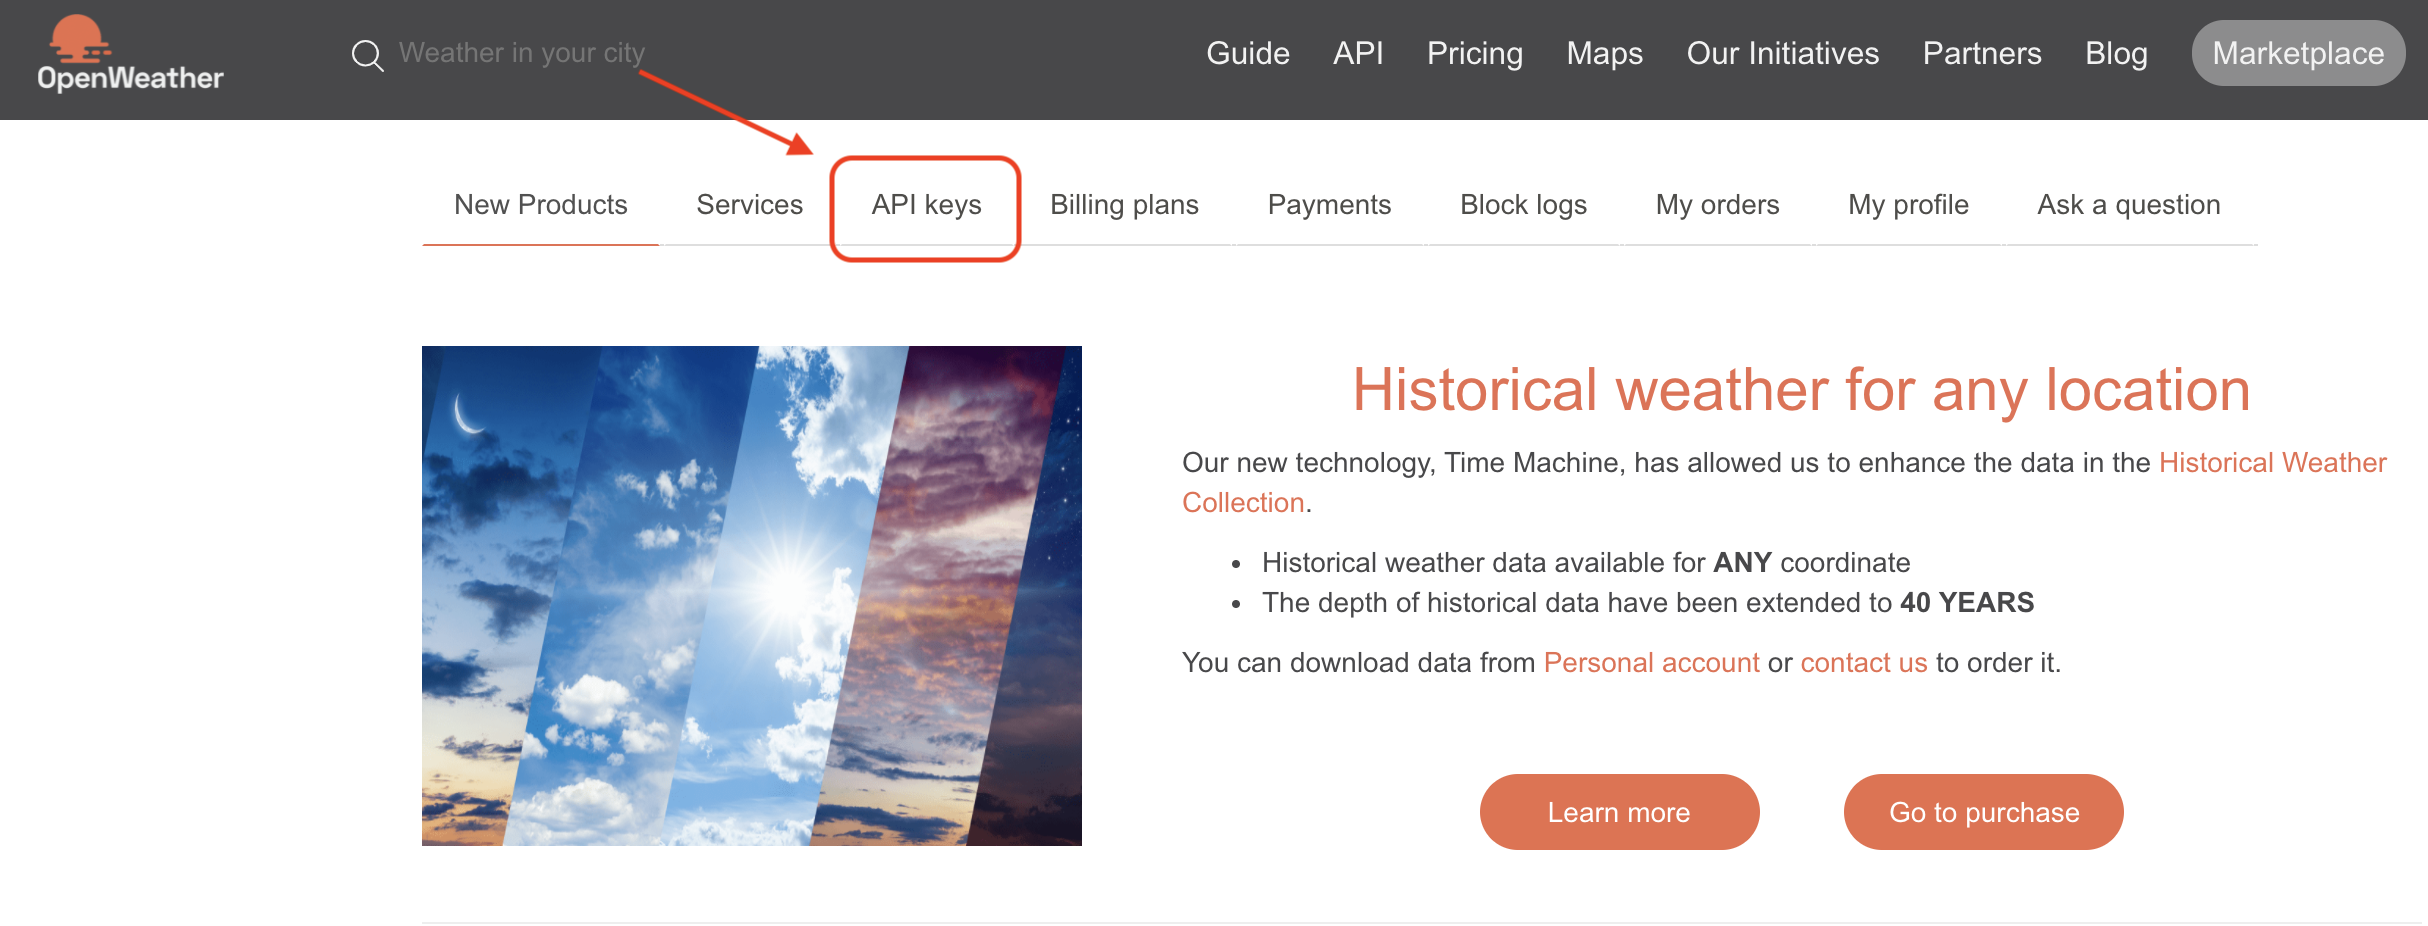

Once you click "API keys", you should be taken to a page that lists your API keys like the one below (you should have one key, whereas I have two listed here):

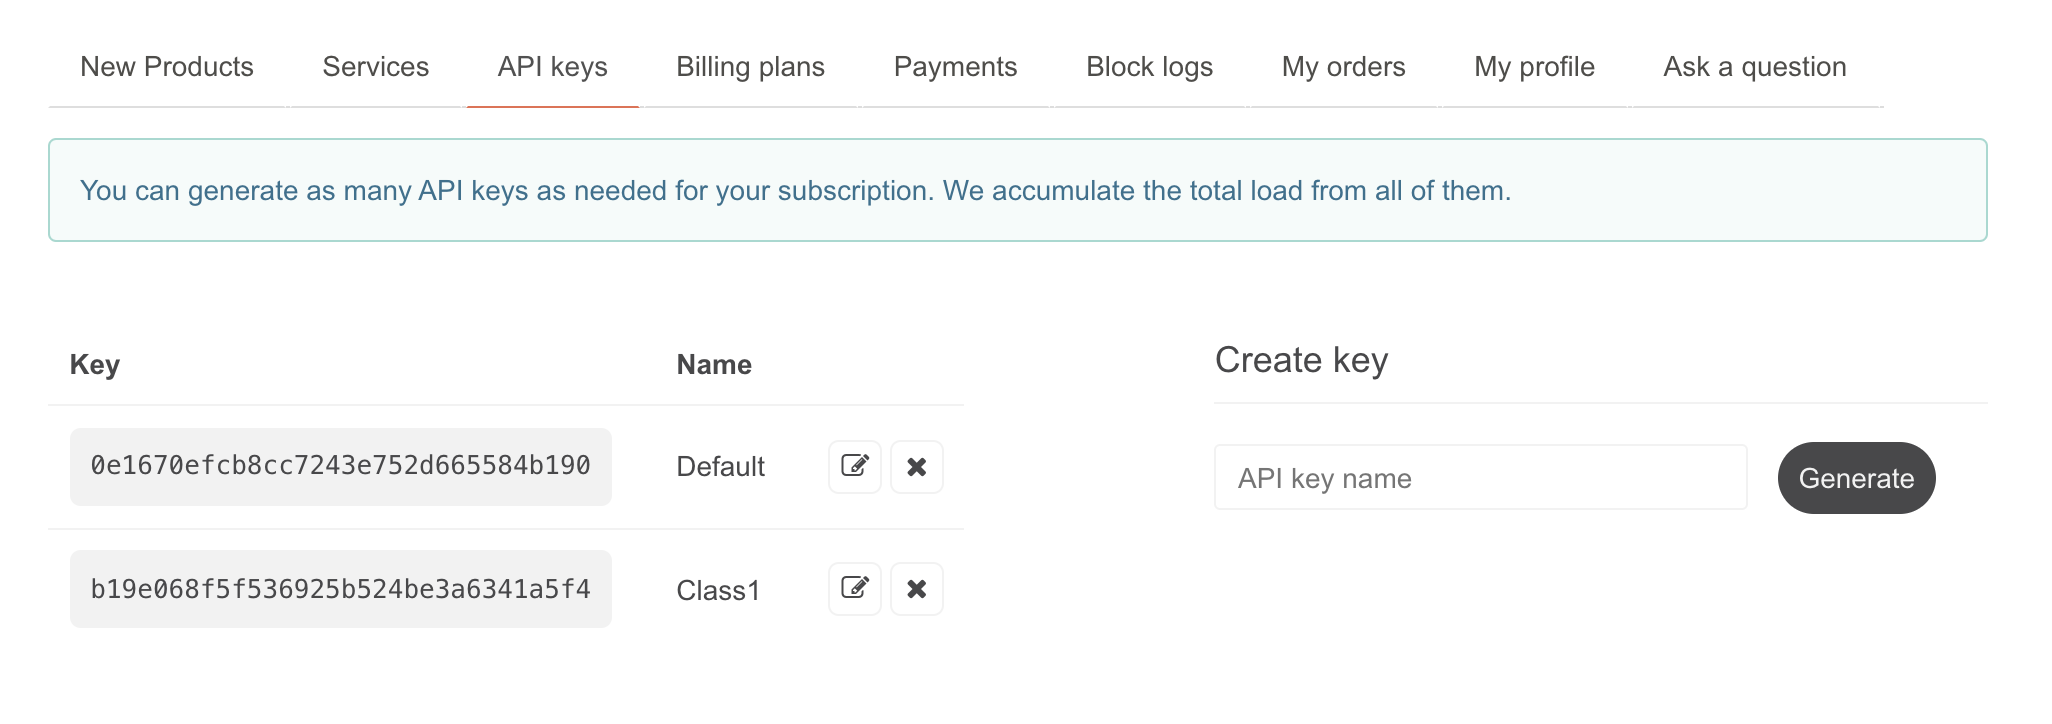

You need to include your API key in every API call that you make. It's a good idea to save your API key to a variable so that you don't need to rewrite it every time you need it. Copy your API key and paste it in the code cell below where it says "PUT_YOUR_API_KEY_HERE", then run that code cell.

In [ ]:
apiKey = "PUT_YOUR_API_KEY_HERE"

### Read the Documentation

The first thing that we need to do is understand how to use the API, so let's take a look at the documentation.

Our goal is to get the current weather data for any ZIP code in the United States.

From the home page, we can navigate to the documentation for openweathermap's current weather API by first clicking "API" (if you don't see "API", you may need to first click on an icon that looks like &#9776;):

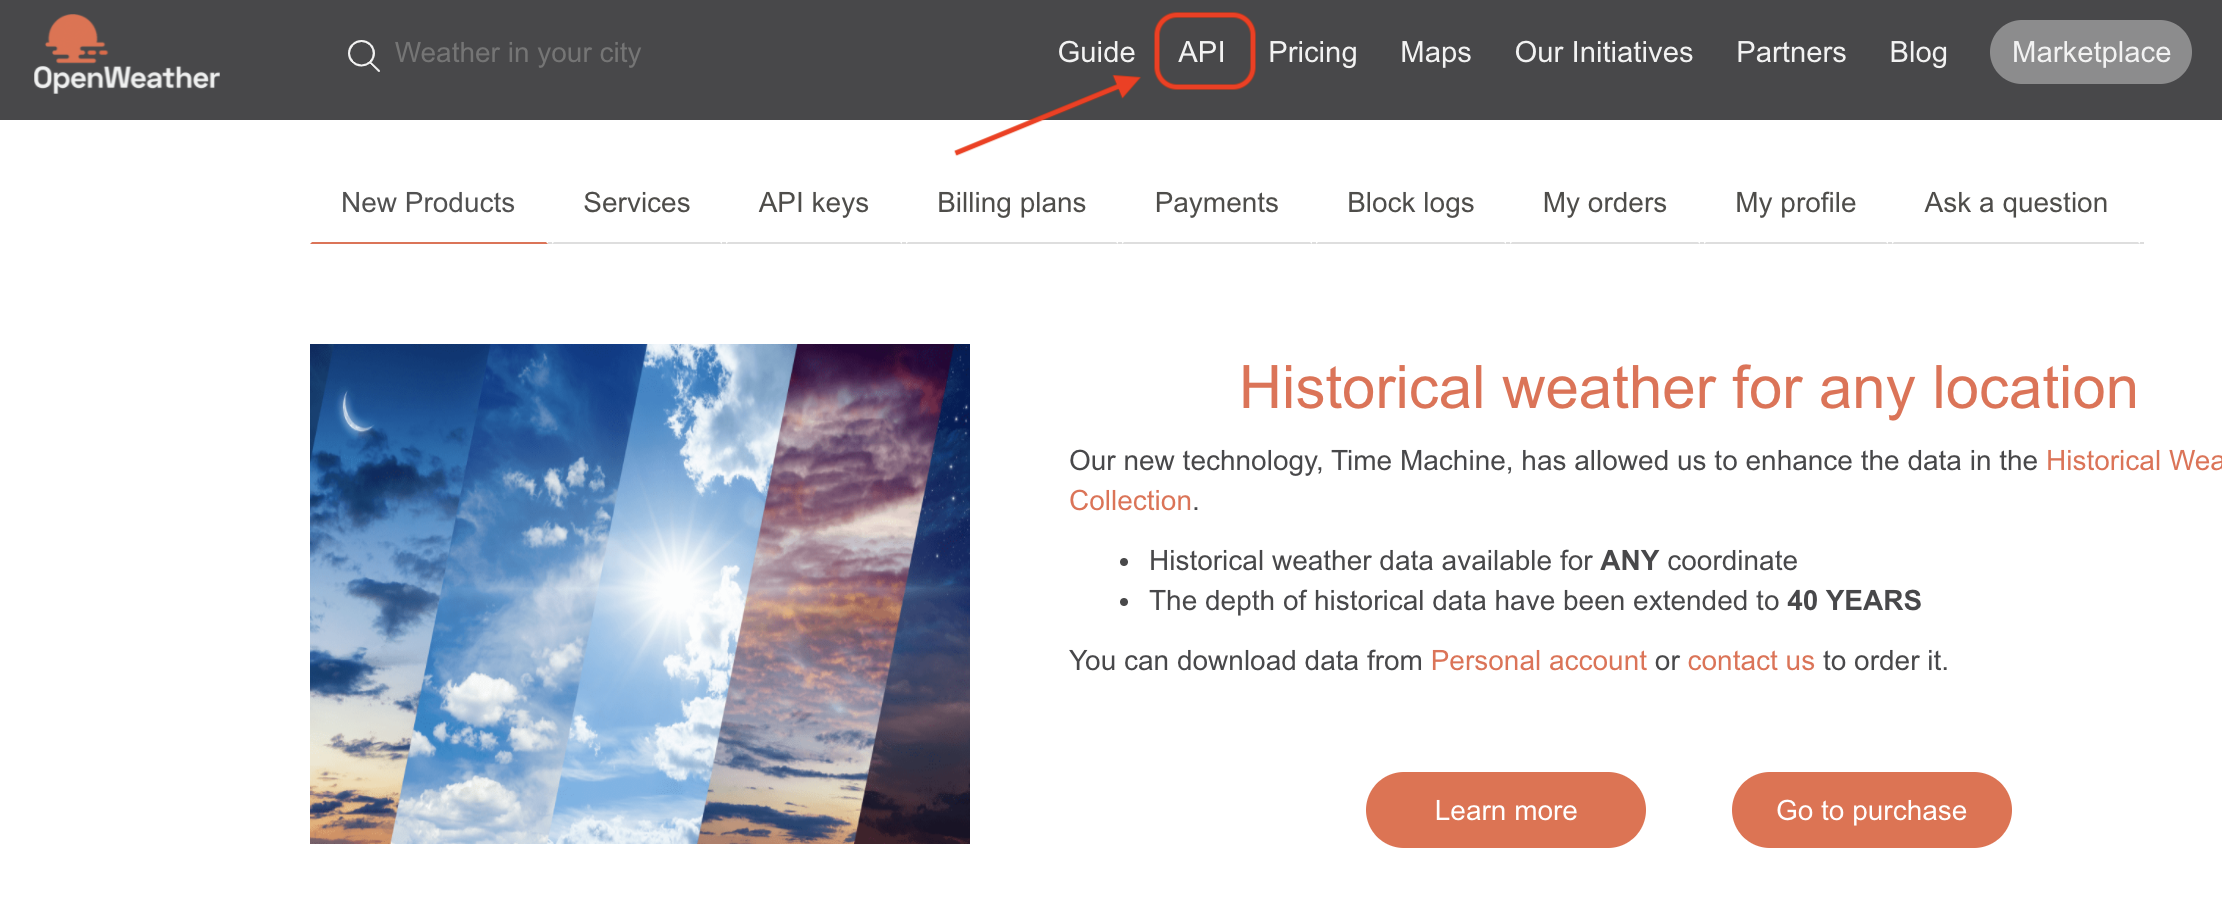

That should take you to a page like the one below, where you need to click "API doc" under the heading "Current Weather Data":

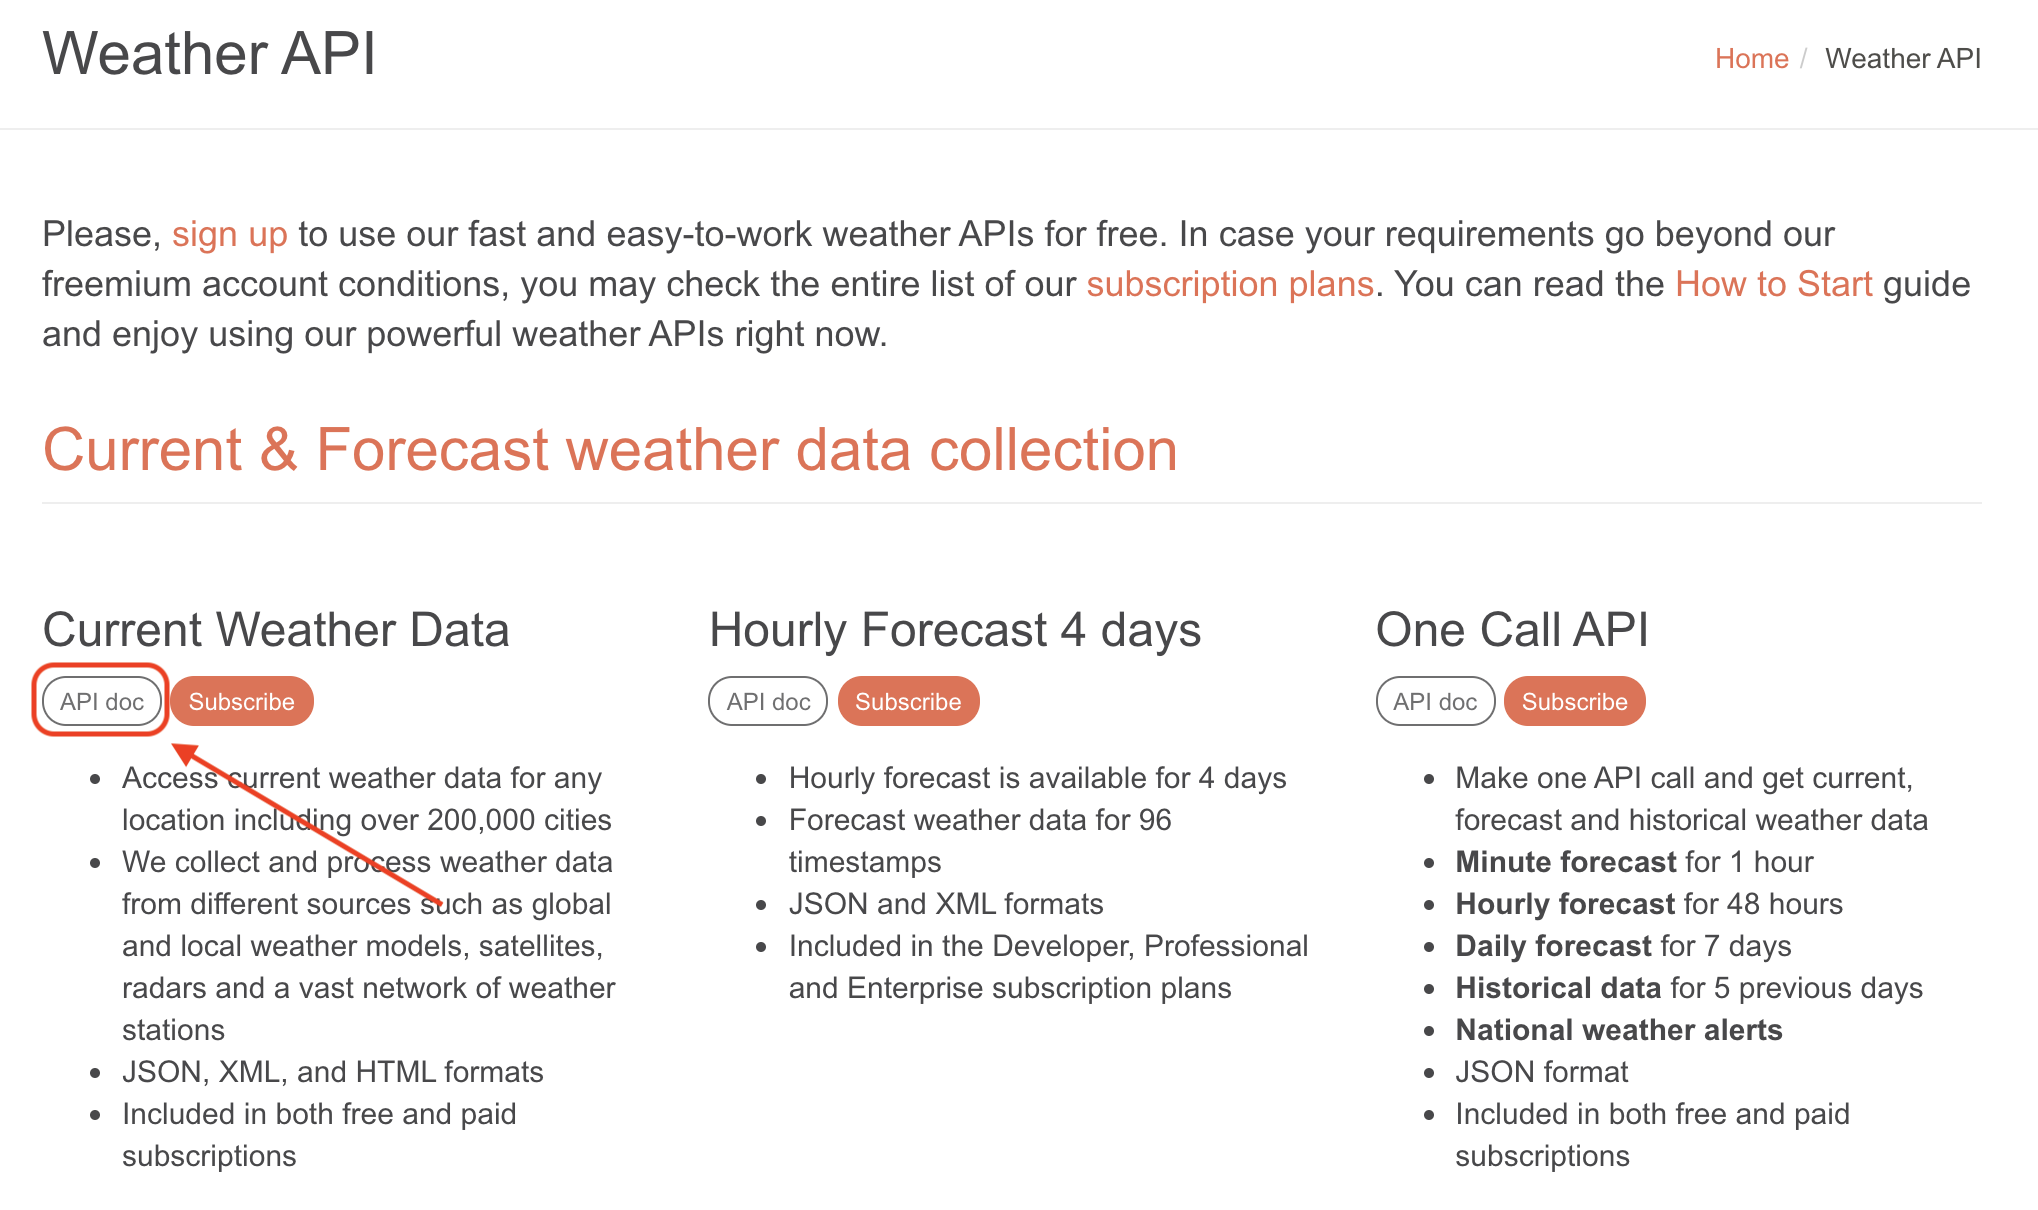

Since we want the current weather of a particular ZIP code, scroll down to the subheading "By ZIP code", which you can also find at the following link: https://openweathermap.org/current#zip

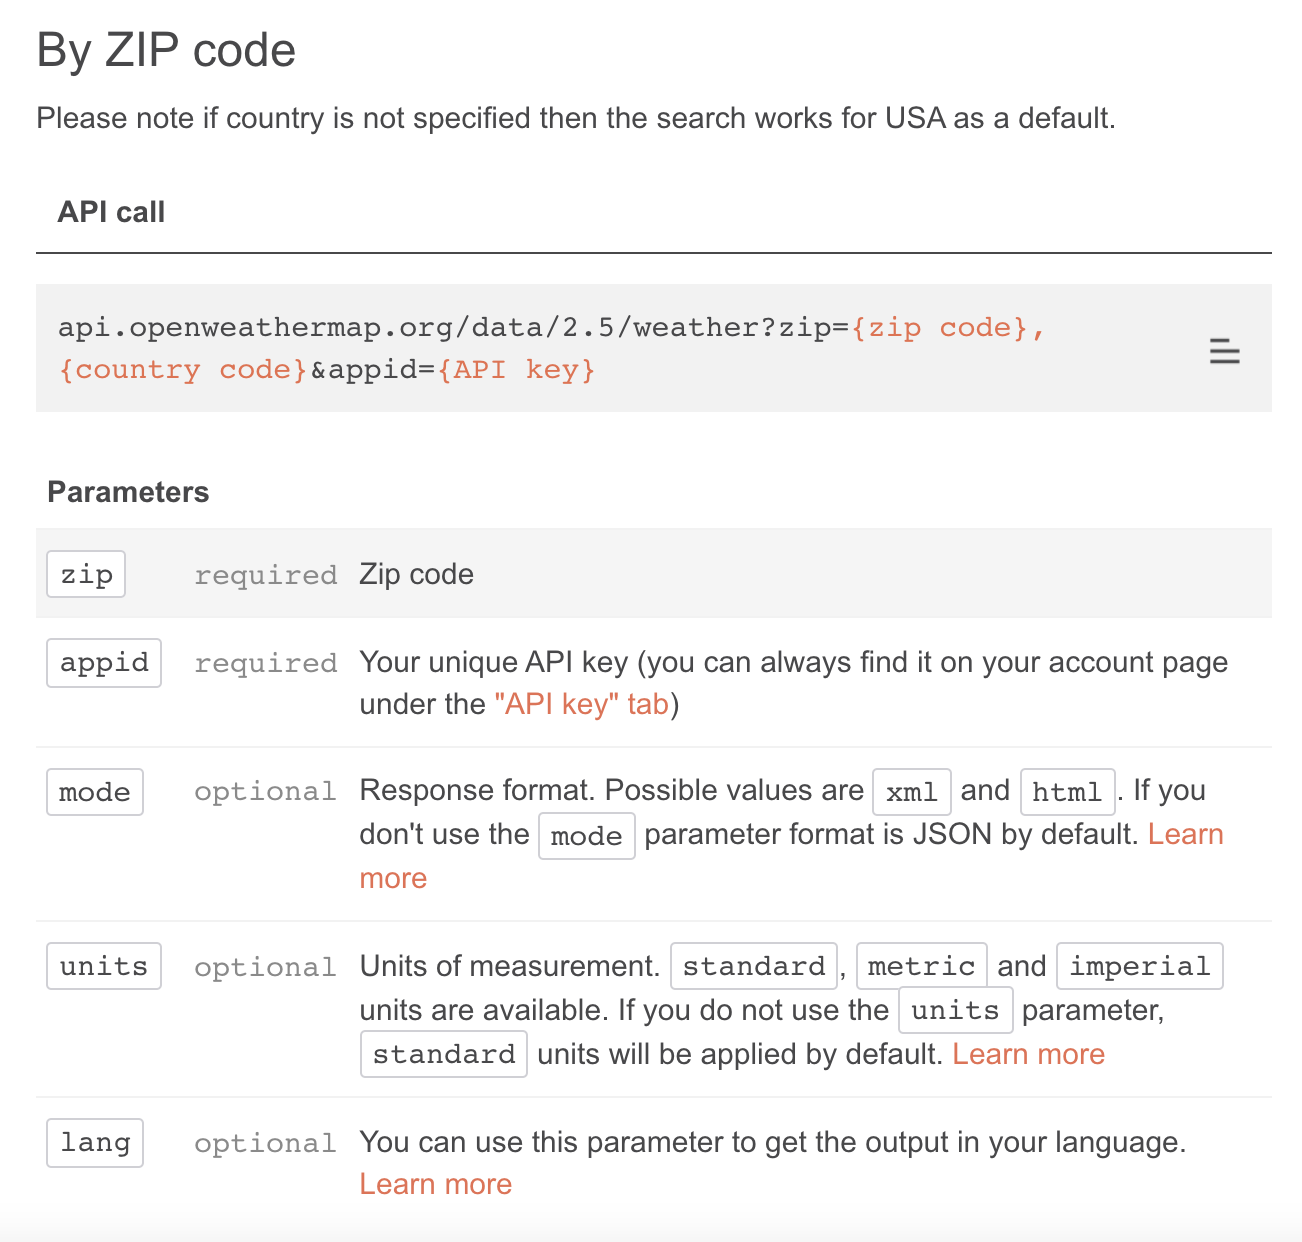

In order to call the API, we just need to go to the website listed under "API call" replacing "{zip code}" with an actual ZIP code and "{API key}" with your API key.

Notice that, aside from "zip" and "appid", which are the ZIP code and your API key, there are a few optional parameters. One of these parameters is "units", which determines whether the temperature is measured in Kelvin, Celsius, or Fahrenheit. If you click "Learn More" in the row for "units", you will see that setting "units" to "imperial" will make your temperature appear in Fahrenheit. We can add this parameter to our API call by adding "&units=imperial" to the end of the URL.

Here is an example of calling the API from a browser to get the current weather in the ZIP code 11385 in Fahrenheit:

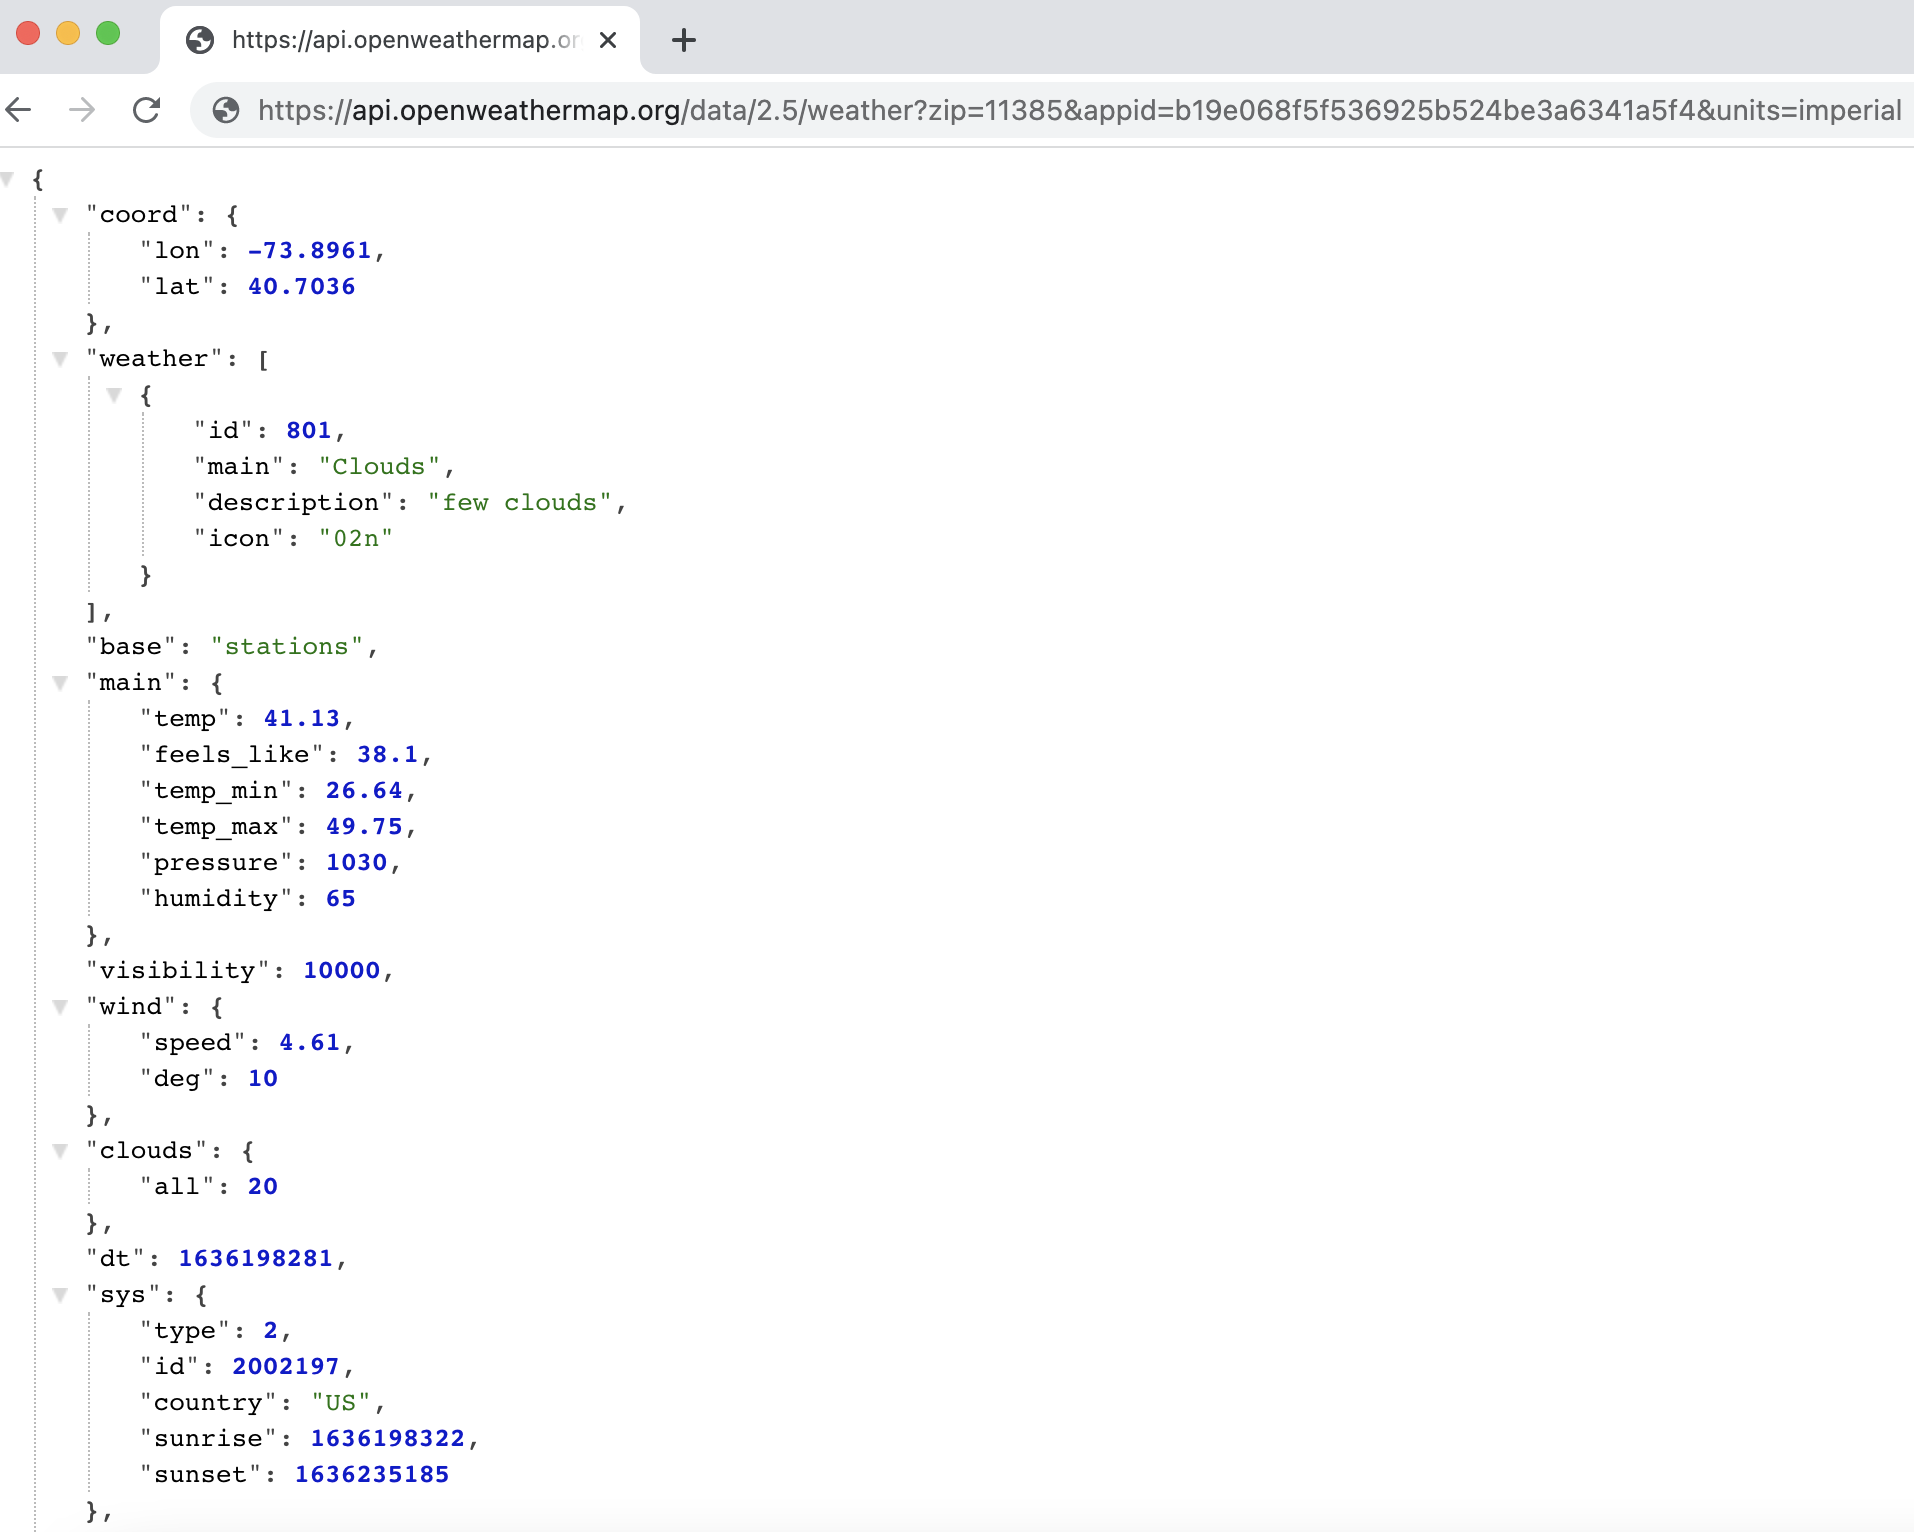

### Call the API

We need the requests library to call the API and Python's built-in JSON library to deal with the response. In the next code cell we import both of these libraries.

In [ ]:
import json
import requests

We can then call the API. The following code cell assumes that you've set the apiKey variable in [this code cell](#scrollTo=5qZD3wVg7k5i).

This API call gets the current temperature for the ZIP code 11385 in Fahrenheit. We then use json.loads to turn the response we get from the API into a Python object.

In [ ]:
page = requests.get(f"https://api.openweathermap.org/data/2.5/weather?zip=11385&appid={apiKey}&units=imperial")
weatherJSON = json.loads(page.content)
weatherJSON

Now that we have the JSON data from our API call converted to a Python object, how can we extract the information we need from it?

### Extract the Data

Our goal is to get the following pieces of information:


1.   Current temperature
2.   Feels like temperature
3.   Minimum daily temperature
4.   Maximum daily temperature
5.   Humidity
6.   Description of weather conditions

Let's start with the current temperature. First, we need to locate the current temperature in the response:

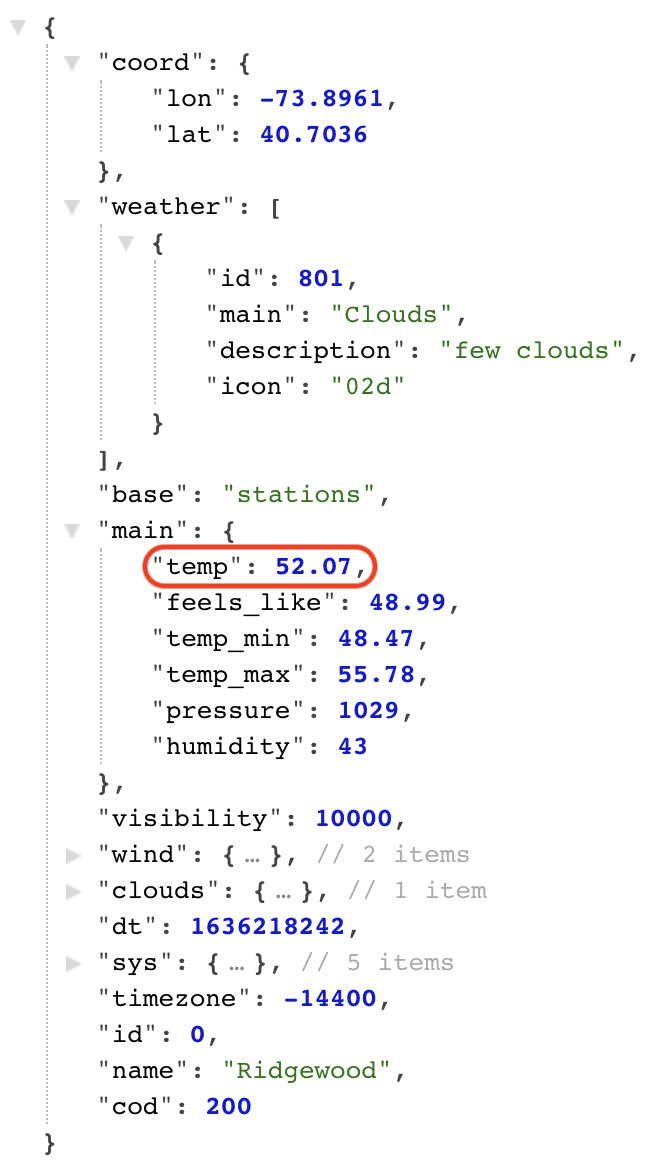

We see that the value for the current temperature is associated with the key "temp". The object containing the key "temp" is the value associated with the key "main". "main" is a key of the entire object, so this means that to access the current temperature, first we use the "main" key, then we use the "temp" key.

In [ ]:
currTemp = weatherJSON["main"]["temp"]
print(f"Current temperature: {currTemp}")

Similarly, to get the feels-like temperature, we notice that that value is associated with the key "feels_like", and that the object containing the key "feels_like" is the value associated with the key "main". This means that to access the feels like temperature, first we use the "main" key, then we use the "feels_like" key.

In [ ]:
feelsLikeTemp = weatherJSON["main"]["feels_like"]
print(f"Feels like temperature: {feelsLikeTemp}")

We can do the same for most of the other pieces of information we were looking for.

In [ ]:
minTemp = weatherJSON["main"]["temp_min"]
print(f"Minimum daily temperature: {minTemp}")

maxTemp = weatherJSON["main"]["temp_max"]
print(f"Maximum daily temperature: {maxTemp}")

humidity = weatherJSON["main"]["humidity"]
print(f"Humidity: {humidity}")

Obtaining the weather description is more complicated, but not by much. We notice that the weather description is the value associated with the key "description". The object with the key "description" is the first element of an array, so we will need to use the index 0 to access that object. That array is the value associated with the key "weather", and "weather" is a key of the entire object. This means that to access the weather description, we will need to use the key "weather", then the index 0, then the key "description".

In [ ]:
description = weatherJSON["weather"][0]["description"]
print(f"Description of current weather conditions: {description}")

With that, we have obtained all of the information we were looking for from the API response. To expand on this, we can write a function that takes in a ZIP code and returns a dictionary of all of the weather data we care about, which is what we do in the following code cell (this assumes that you've set the apiKey variable in [this code cell](#scrollTo=5qZD3wVg7k5i)).

In [ ]:
def getWeatherByZipCode(zipCode):
    """
    Returns weather information for the zip code indicated by the argument

    zipCode should be a 5-digit string
    """
    page = requests.get(f"https://api.openweathermap.org/data/2.5/weather?zip={zipCode}&appid={apiKey}&units=imperial")
    weatherJSON = json.loads(page.content)

    #current temp
    currTemp = weatherJSON["main"]["temp"]

    #feels like temperature
    feelsLikeTemp = weatherJSON["main"]["feels_like"]

    #minimum daily temp
    minTemp = weatherJSON["main"]["temp_min"]

    #maximum daily temp
    maxTemp = weatherJSON["main"]["temp_max"]

    #humidity
    humidity = weatherJSON["main"]["humidity"]

    #description
    description = weatherJSON["weather"][0]["description"]

    return {
        "currTemp": currTemp,
        "feelsLikeTemp": feelsLikeTemp,
        "minTemp": minTemp,
        "maxTemp": maxTemp,
        "humidity": humidity,
        "description": description
    }

In [ ]:
#here we test the above function with the ZIP code 11237
getWeatherByZipCode("11237")

### Places to Continue Learning

* [Installing Python](https://realpython.com/installing-python/)
    * If you would like to run Python code without requiring an internet connection, you need to install it locally on your computer. This link contains great instructions on how to do that.
* [Automate the Boring Stuff with Python by Al Sweigart](https://automatetheboringstuff.com/)
    * This is a great book that shows how to write Python programs that perform useful and time-consuming tasks in a fraction of a second. One of the topics the author discusses is working with JSON data (Chapter 16), and he uses the same API that we used in this class.
* [JSON documentation](https://www.json.org/json-en.html)
* [Open Weather Map documentation to get current weather](https://openweathermap.org/current)



In addition to the above resources, NYPL offers free courses on Linkedin Learning to anyone with a library card. We recommend the following courses on that platform:
* Working with Databases
    1. [MySQL Installation and Configuration](https://www.linkedin.com/learning/mysql-installation-and-configuration/)
        * After obtaining data through an API, we may need some place to store that data. For that, we could use a database. MySQL is a free, popular database management system, and this course covers how to install and set it up.
    2. [Advanced Python: Working with Databases](https://www.linkedin.com/learning/advanced-python-working-with-databases)
        * Chapter 3 of this course covers how to use MySQL with Python.
    3. [MySQL Essential Training](https://www.linkedin.com/learning/mysql-essential-training-2?u=73722380)
        * This course covers how to use MySQL in general and also serves as a good introduction to SQL, the most common language used to communicate with databases.
* [Python Data Analysis](https://www.linkedin.com/learning/python-data-analysis-2/)
    * This is a course on data analysis in Python. It covers Python data structures like lists, tuples, dictionaries, and sets; great features in Python like comprehensions and the collections and itertools modules; and it spends a lot of time talking about numpy and pandas, which are great for dealing with data and doing math with it.
* [Python for Data Science Essential Training](https://www.linkedin.com/learning/python-for-data-science-essential-training-part-1/)
    * This is a comprehensive course on data science in Python.